### ISA Project- Part 1

**Title: Analyzing Solar Imagery and Identifying Active Regions using Aditya-L1 Data**

The image downloaded for the analysis is dated **09-05-2026** at **07:09:21 AM**. 

The image is a level 1 image. 

**NOTE:** The image is an off centered image of the sun which means that there are strong distortions in the western and southern hemispheres as mentioned in the PRADAN portal. 

The image is filtered using the onboard **NB03** filter (central wavelength = 279.6 nm, bandpass = 0.4nm)

## Importing necessary libraries-

In [2]:
# Imports:

import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from astropy.io import fits
import sunpy.map 

from suitcolormap import suit_cmap, suit_norm
from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.measure import regionprops
from sunpy.net import attrs as a
from sunpy.net import Fido
from skimage import measure
import astropy.units as u
from sunpy.coordinates import HeliographicStonyhurst

**Loading the FITS file in our Notebook**

In [3]:
# Loading the file: 

# we will now load the FITS file to the notebook and view the raw image: 
smap = sunpy.map.Map(r'..\Data\Raw\SUT_T26_0649_002132_Lev1.0_2026-05-09T07.09.21.400_08B2NB03.fits')

## Displaying the Raw Image-

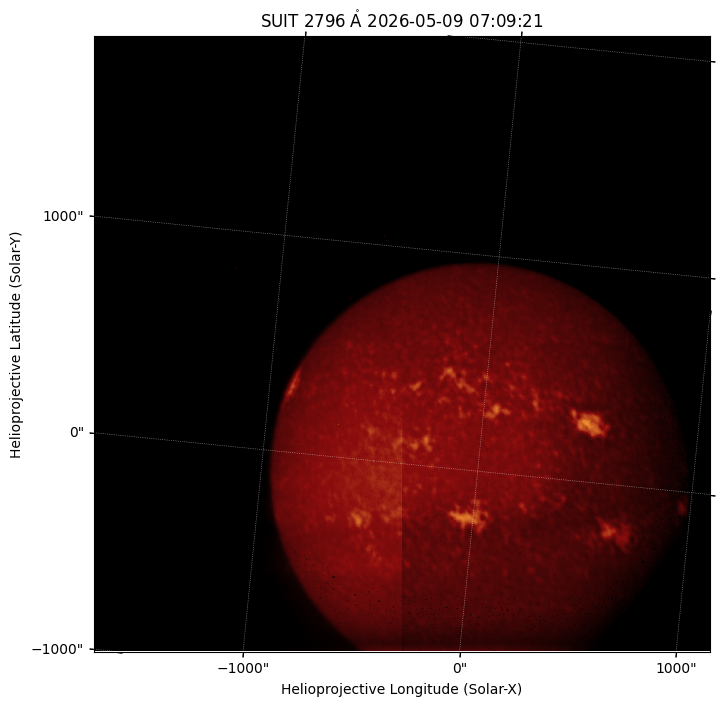

In [4]:
cmap = suit_cmap('NB03')  # We have taken data from NB03 filter, hence we need to implement its color map.
plt.figure(figsize=(8,8))
smap.plot(cmap=cmap, vmin=100)
plt.savefig(r'../Outputs/Figures/Fig.1_Raw_Image.png', dpi=150, bbox_inches='tight')
plt.show()
  
# We have taken a custom vmin value to ensure that we can differentiate sun from background.

**NOTE**:

 PRADAN portal warns- SUIT data taken in the off-centered position is highly distorted in the southern and western hemispheres. This needs to be taken into account for our analysis.

We have successfully imported the FITS file and displayed raw image in our notebook. We will now perform preprocessing of this image in order to convert this image from level 1 to level 2.  

## Understanding Data using Visualization:

Before we move on to make corrections to the raw image it is necessary for us to understand the data properly. For this, I have plotted the histogram of the data points so that we can have a clear picture of what stands before us.

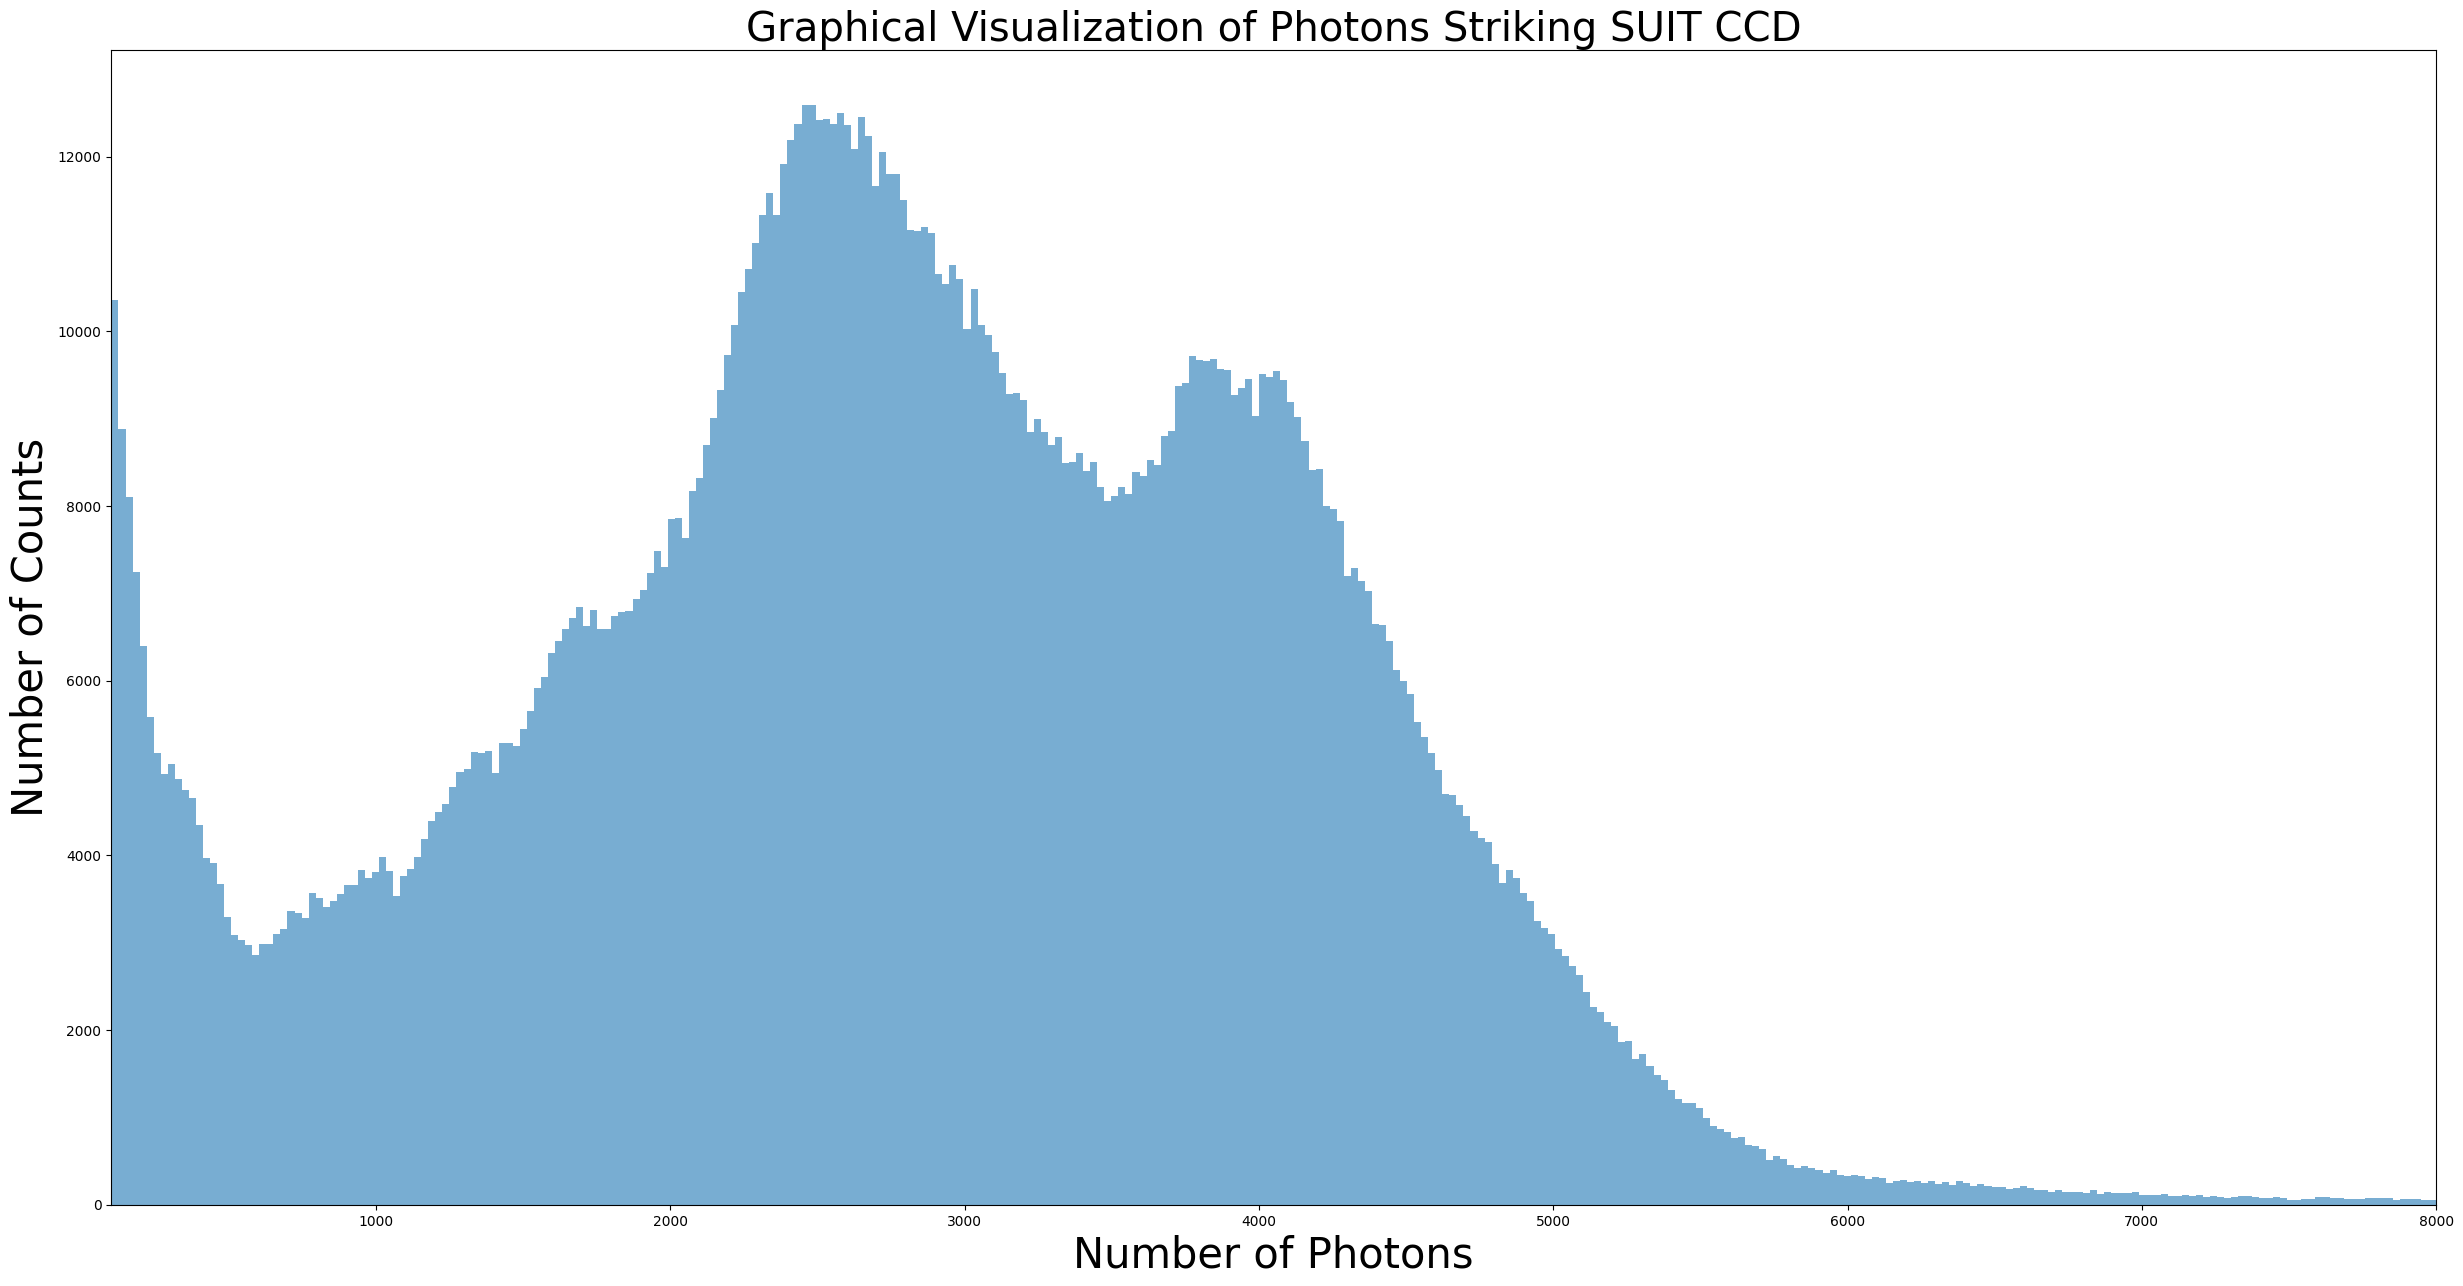

In [5]:
arr_2d = smap.data     # 2048 x 2048 array
# arr_2d is the array in which each element  corresponds to photon count on each pixel of SUIT. 

arr_1d = arr_2d.flatten()   # Converting 2D array to 1D for the sake of histogram plotting.
'''The array consists of many negative values which have no physical significance. They do not have any role to play in our analysis
and so we will remove them.'''
arr_1d[arr_1d<0]=0
arr_solar = arr_1d[arr_1d>100]  # This has been done to visualize the data properly and draw some fair conclusions.
plt.figure(figsize=(30,15))
plt.hist(arr_solar, bins=1000, alpha=0.6)
plt.xlim(100,8000)
plt.xlabel('Number of Photons', fontsize= 30)
plt.ylabel('Number of Counts', fontsize=30)
plt.title('Graphical Visualization of Photons Striking SUIT CCD', fontsize = 29)
plt.show()

The following observations can be made from the histogram: 

1. We can see that two distinguishable peaks are formed in our graph. These peaks are of physical significance, both of them correspond to physical phenomena: 
   
   **a**. The first peak (from left), sitting around at 12000 counts, corresponds to the quiet part of the sun that is the regions of sun except the active regions.
   
   **b**. The second peak- close to 10000 counts- corresponds to the solar limb or chromospheric limb. As can be seen from the graph it is brighter than the quiet sun but less bright than active regions of the sun. 
2. The region of the graph corresponding to the active regions is the region after the second peak. Their count may be less but, they are brighter than rest of the sun. There is a reason why they are less in count, it i because they cover very less area of the sun's surface which can also be seen from our graph.     
3. There is also another peak which is located near the origin, this is concerning for us from the perspective of performing Otsu thresholding. Otsu's algorithm works best on bimodal distribution but, this peak is creating a disturbance to bimodality of the data. This can be termed as one of the limitations of Otsu's algorithm as more will follow. 

## Flat-Field Correction:

**Flat-field correction is done to make for the errors which arise due to difference in sensitivity of the pixels which leads to artificial counts.
It smoothens the abrupt rises and falls in the plot and only keeps the smooth variations. 
This is done by applying uniform filter. Each output pixel is the average of all pixels in the neighborhood.**

Ideally it is done by pointing telescope at a perfectly uniform light source and record the response. But we don't have a calibrated image as of now. Hence, we will estimate it from data itself.
 
This is achieved by applying uniform filter to our array **arr_2d** with a size suitable as per the data size.

In [6]:
arr_2d[arr_2d<0] = 0       # As mentioned before, negative values have no physical significance.
flat_field = uniform_filter(arr_2d, size=100)    # This is the value of flat-field calculated directly from the data we have.
'''We have selected size=100 as it not compromising the spatial details of detector and also gives us a valid enough flat field to work with.'''

# Applying correction: 
flat_field[flat_field<1]=1   # This is being done to prevent the division of arr_2d from 0 as flat_field contains many 0 values.
arr_ffc = arr_2d/flat_field * np.median(flat_field[flat_field>1]) 


We have applied flat field correction to our image and now we will plot the image to see the effect it has on our raw image.

**arr_ffc** is the array containing the flat field corrected values. To generate an image out of this array we will have to use **'imshow'** function for it which is present in **matplotlib**.

## Generating Flat Field Corrected Image:

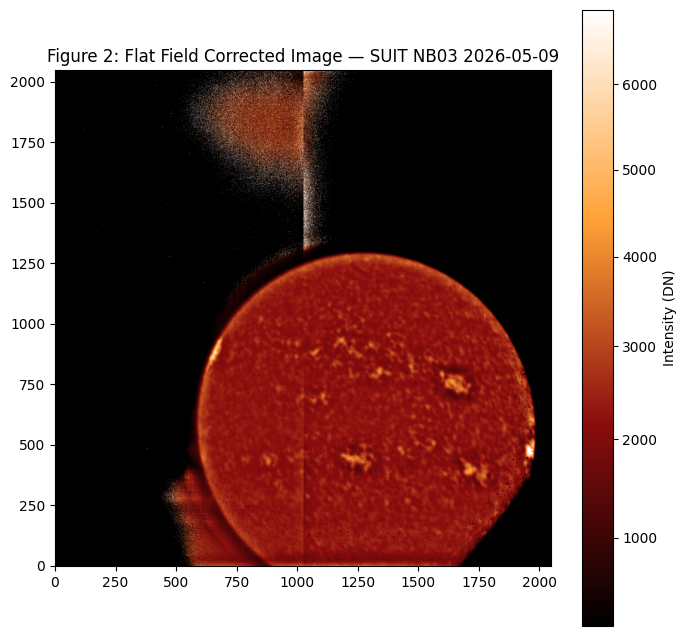

In [7]:
cmap = suit_cmap('NB03')            # The colormap of 'NB03' being chosen.
norm = suit_norm(arr_ffc, 'NB03')   # Norm correspnding to SUIT NB03.

plt.figure(figsize=(8,8))
plt.imshow(arr_ffc , cmap = cmap, norm = norm, origin = 'lower')
plt.title('Figure 2: Flat Field Corrected Image — SUIT NB03 2026-05-09', fontsize= 12)
plt.colorbar(label='Intensity (DN)')
plt.savefig(r'../Outputs/Figures/Fig.2_Flat_Field_Corrected_Image.png', dpi = 150, bbox_inches= 'tight')
plt.show()


## Some notable observations: 

**1.** There are some high distortions that can be seen in the image. Let us mention them in brief: 

  **a.** There is a high distortion in the off disk area located above the solar disk.

  **b.** A high distortion- once again off-disk- exists at the bottom left of the solar disk.

  **c.** There is a vertical stripe inside the solar disk at around x=1000.

  **d.** There is also a horizontal stripe which is at the region where sun disk is meeting the graph. It runs from around x=1000 to around x=1750.

The distortions mentioned in points **a** and **b** are called artifacts and as can be seen are unusually bright even comparable to active regions.

**2.** The active regions in the sun are clearly visible as bright patches, in comparison to the quiet sun, on the solar disk.

**3.** Before we proceed to Otsu thresholding, we would have to take care of the artifacts that are there in the image. Without their removal Otsu thresholding will be pulled in wrong place. This can be done by masking.

## Normalization: 

Normalization is done to rescale the data to standard range (usually: 0 to 1) so that comparisons between images becomes meaningful and algorithms like Otsu work properly. What it does is, it basically eliminates the factors which don't affect solar physics.

There are many types of normalization like min-max, logarithmic, percentile, etc. For our analysis percentile normalization is most suitable because our data contains outliers with a very high value (Highest number of photons: 24027), percentile noralization reduces their effect along with the preservation of contrast.

**arr_normalized** is the array containing normalized values.

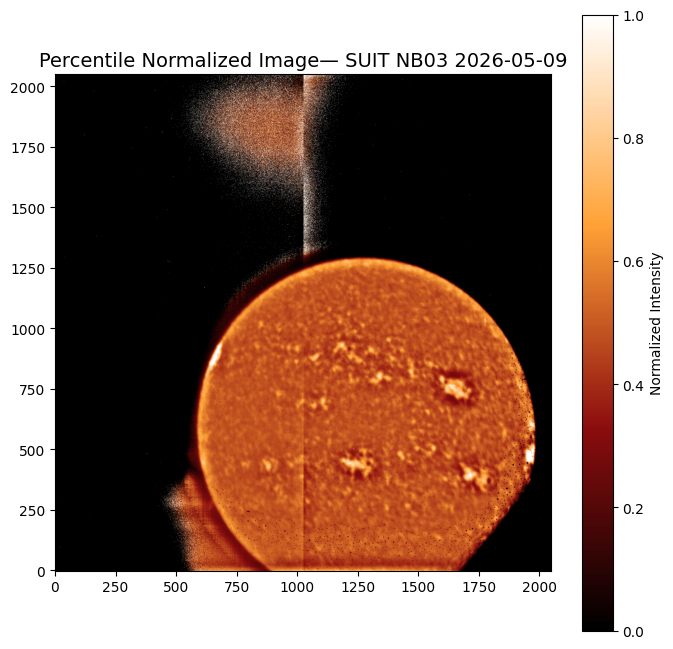

In [8]:
# Applying Percentile Normalization:
P1 = np.percentile(arr_ffc, 1)     # 0
P99 = np.percentile(arr_ffc, 99)   #4658.8745
arr_normalized = (arr_ffc-P1)/(P99-P1)  # Normalized array.
arr_normalized = np.clip(arr_normalized,0,1)  # so that all values stay between 0 and 1
plt.figure(figsize=(8,8))
plt.imshow(arr_normalized, cmap = cmap, origin = 'lower')
plt.colorbar(label='Normalized Intensity')
plt.title('Percentile Normalized Image— SUIT NB03 2026-05-09', fontsize=14)
plt.savefig(r'../Outputs/Figures/Fig.3_Percentile_Normalized_Image.png', dpi=150, bbox_inches='tight')
plt.show()

## Working on the Removal of Distortions (Masking):
Now we are going to resolve the problem of high distortion in the western and southern hemisphere. This can be done by removing the off-disk background of the image, this will neglect everything that is outside the solar disk. We will do it by **masking**.

We will try to create an array which contains the values only for the solar disk, although this can't be perfect but, we will try to minimize distortions as much as possible without compromising solar disk.

The values of radius and coordinates of center of the disk have been multiple times iterated manually to get to the result with minimum distortions.

In [9]:
# Masking the solar disk: 

x = np.arange(0, 2048)  # Creating 2 lists having values from 0 to 2047 for locating every pixel on the image as its resolution is 2048*2048.
y = np.arange(0, 2048)
X, Y = np.meshgrid(x, y)
radius = 775
x_center = 1320
y_center = 650
distance = np.sqrt((X-x_center)**2+(Y-y_center)**2)
mask = (distance<=radius)    # mask is a 2048*2048 boolean array.

arr_2d_masked = arr_normalized.copy()  
arr_2d_masked[~mask] = 0 # Unmasked values of arr_2d_masked being given the value of 0.

## Masked Image:

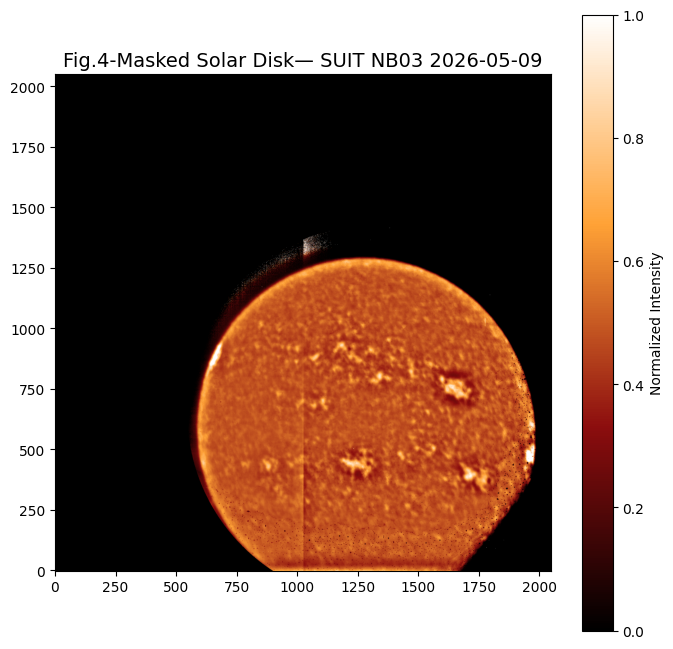

In [10]:
#Image of masked solar disk: 

plt.figure(figsize=(8,8))
norm = suit_norm(arr_2d_masked,'NB03')
plt.imshow(arr_2d_masked, cmap=cmap, origin='lower')
plt.colorbar(label='Normalized Intensity')
plt.title('Fig.4-Masked Solar Disk— SUIT NB03 2026-05-09', fontsize=14)
plt.savefig(r'../Outputs/Figures/Fig.4_Masked_Solar_Disk_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

We can see that the masked image contains very less distortions from the previous images without compromising any features of solar disk. The distortion on the bottom left is almost eliminated and that above solar disk also removed to a large extent but, even now the image is not completely free from artifacts. This means that the masking is not perfect but still it is largely useful.

## Detecting Active Regions using Otsu Thresholding

We now apply Otsu thresholding to the flat-field corrected, normalized and masked solar disk image to isolate the active regions. Otsu's method automatically finds the optimal threshold by minimizing intra-class variance. We apply it only within the solar disk mask to avoid background pixels from skewing the threshold. But, before we apply thresholding to the image let us take a look at the histogram of the array that we have now after appling ffc, normalization and masking to enhance our understanding of the image. 

**Histogram Analysis of flat-field corrected, normalized and masked solar disk:**

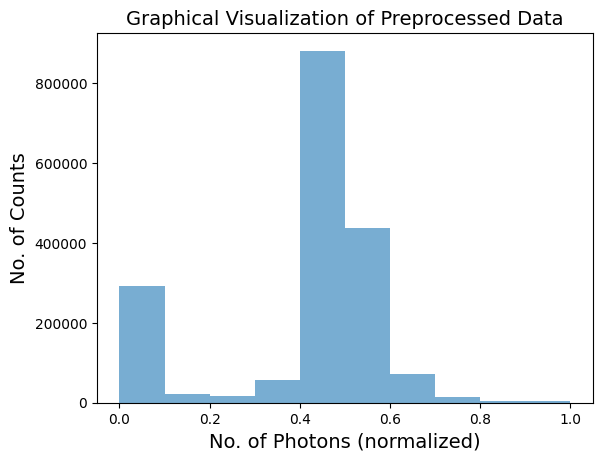

In [11]:
sun_pixels_only = arr_2d_masked[mask]   # it is masked version of arr_2d_masked
plt.hist(sun_pixels_only, alpha=0.6)
plt.xlabel('No. of Photons (normalized)', fontsize=14)
plt.ylabel('No. of Counts', fontsize=14)
plt.title('Graphical Visualization of Preprocessed Data', fontsize=14)
plt.show()

**Observations:**

We can see from the above graph that it has a peak at  nearly 0-0.1. The reason for this peak is that our masking is not perfect as mentioned earlier. Some off disk background is still in the masked image. Due to the presence of this off disk region, some part of artifacts is still the part of our image. 

This will be problematic for our Otsu thresholding as the algorithm searches for two peaks and assigns threshold in between those peaks in a valley. Under the present conditions, it is very likely that Otsu will identify the peaks at 0-0.1 and 0.4-0.5 as the two distinguishable peaks and will assign a threshold in between these two peaks which is wrong as it will mean that a lot of quiet sun will be labelled as active region.
To get rid of this error we would have to remove this very first peak.

**Fixing the off-disk error:**

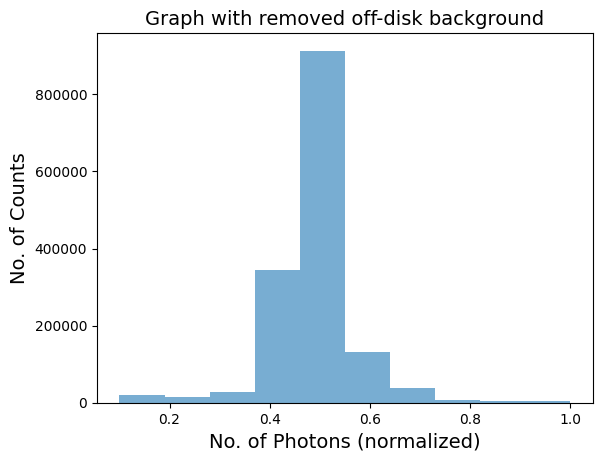

In [12]:
# Fixing the off disk background in the masked image: 
sun_pixels_filtered = sun_pixels_only[sun_pixels_only>0.1]  
# We have created a new array which has values greater than 0.1. This way the first peak is essentially clipped.
plt.hist(sun_pixels_filtered, alpha=0.6)
plt.title('Graph with removed off-disk background', fontsize=14)
plt.xlabel('No. of Photons (normalized)', fontsize=14)
plt.ylabel('No. of Counts', fontsize=14)
plt.show()

## Observations: 

We have successfully removed the peak corresponding to 0-0.1 but, this has created another problem for us. After the removal of that peak we are now left with a single peak. For Otsu's algorithm to work properly bimodal distribution is needed so that a proper threshold value is assigned. 

While Otsu's algorithm seemed perfect when we analysed raw data's histogram, now after making some corrections to the raw data and analysing it, we can see that it will not be of that utility as it was earlier because the data is no longer bimodal. This means that the scope for error has increased.

The array **sun_pixels_filtered** is the array containing normalized values greater than 0.1.

Otsu threshold value = 0.5341811180114746


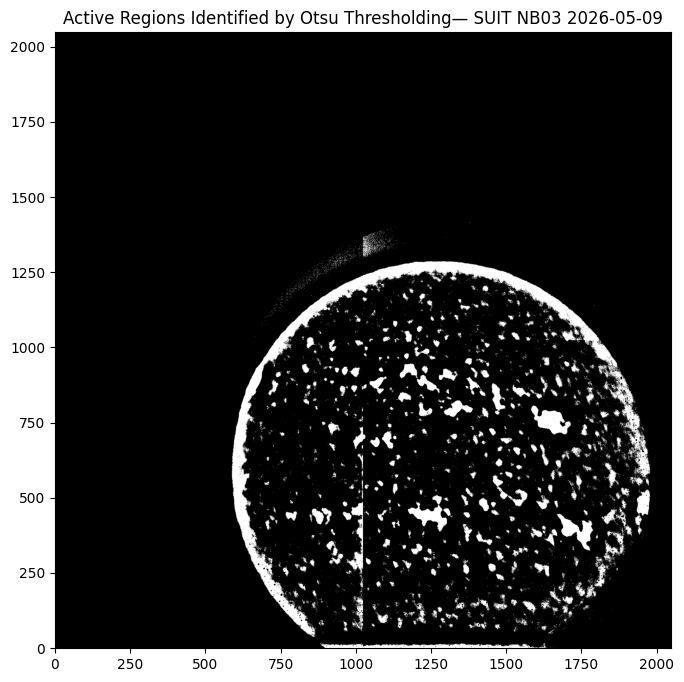

In [13]:
sun_pixels_only = arr_2d_masked[mask]

threshold_value = threshold_otsu(sun_pixels_filtered)
print(f'Otsu threshold value = {threshold_value}')  
active_region_mask = (arr_2d_masked>threshold_value) & mask   # Creating an array which fulfils the Otsu threshold condition and is masked

plt.figure(figsize=(8,8))
plt.imshow(active_region_mask, cmap=cmap,origin='lower')
plt.title('Active Regions Identified by Otsu Thresholding— SUIT NB03 2026-05-09')
plt.savefig(r'../Outputs/Figures/Fig.5_Active_Regions_Image.png', dpi=150, bbox_inches='tight')
plt.show()

## Observations: 

1. The image generated using Otsu's Algorithm identifies both active regions and solar limb (the circular shell along the perimeter of the solar disk) along with some other patches on the solar disk as active region. 

2. The artifacts in the image are also identified as active regions. This is due to the reason that Otsu's algorithm uses intensity distribution only to classify a region as active or quiet. This is another limitation of this method. 

3. The active regions identified in this image are occupying an area which is much larger than that occupied by active regions. Typically, active regions occupy at most 20% of sun's area and that too when the solar cycle is strong, the current Solar Cycle (SC25) to which our image belongs is a relatively weaker cycle and hence an area this large occupied by active regions is a serious concern.

## Applying Morphological Operations

**As discussed earlier, Otsu's algorithm uses only intensity based classification due to which the solar limb is also identified as active region. To get rid of it and also of the vertical and horizontal patches in solar disk we will be applying morphological operations.** 

**Morphological Operations work on morphology (shape) of regions in an image. Due to this shape based classification we can try and remove the artifacts and horizontal as well as vertical patches on the disk.**

We will begin labeling the active regions of the sun as identified by Otsu's algorithm. 

[np.float64(95884.0), np.float64(7262.0), np.float64(6441.0), np.float64(5717.0), np.float64(5028.0), np.float64(4353.0), np.float64(3376.0), np.float64(2702.0), np.float64(2480.0), np.float64(2135.0), np.float64(2036.0), np.float64(1653.0), np.float64(1627.0), np.float64(1449.0), np.float64(1362.0), np.float64(1320.0), np.float64(1285.0), np.float64(1265.0), np.float64(1225.0), np.float64(1209.0), np.float64(1139.0), np.float64(1066.0), np.float64(1010.0), np.float64(1009.0), np.float64(1006.0), np.float64(981.0), np.float64(914.0), np.float64(907.0), np.float64(897.0), np.float64(862.0), np.float64(861.0), np.float64(848.0), np.float64(833.0), np.float64(807.0), np.float64(792.0), np.float64(792.0), np.float64(787.0), np.float64(781.0), np.float64(768.0), np.float64(753.0), np.float64(733.0), np.float64(712.0), np.float64(701.0), np.float64(673.0), np.float64(665.0), np.float64(660.0), np.float64(659.0), np.float64(656.0), np.float64(642.0), np.float64(632.0), np.float64(632.0), np.f

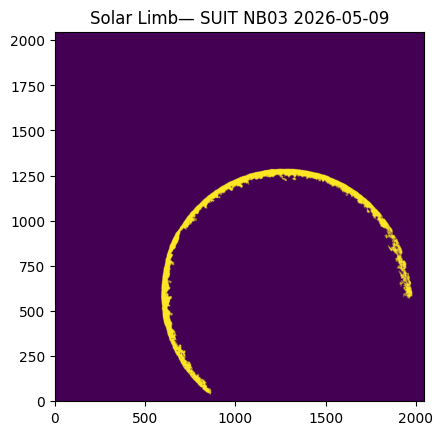

In [14]:
labeled = label(active_region_mask)  #labeled array.
labeled_regions = regionprops(labeled)  #Regionprops is a function that measures a region's properties like label number, area, coordinates, etc. 
lst = []                                # We will store in list the areas of labelled regions in descending order to identify limb. 
for i in range(0,len(labeled_regions)):
    lst.append(labeled_regions[i].area)
lst.sort(reverse= True)
print(lst)

for i in range(0, len(labeled_regions)):
    if (labeled_regions[i].area == 95884):   #Trying to identify the limb by enterring the area manually.
        print(labeled_regions[i].label)

test_label = (labeled == 45)            # Verifying if the label found corresponds to the limb or not. 
plt.imshow(test_label, origin='lower')
plt.title('Solar Limb— SUIT NB03 2026-05-09')
plt.savefig(r'../Outputs/Figures/Fig.6_Solar_Limb_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**We have successfully identified the solar limb label. Now, in order to remove this limb from our image we have to create a maximum threshold area. If size of a label is above that value then the label will be excluded from the array.**

List containing labels having area higher than threshold: [45]


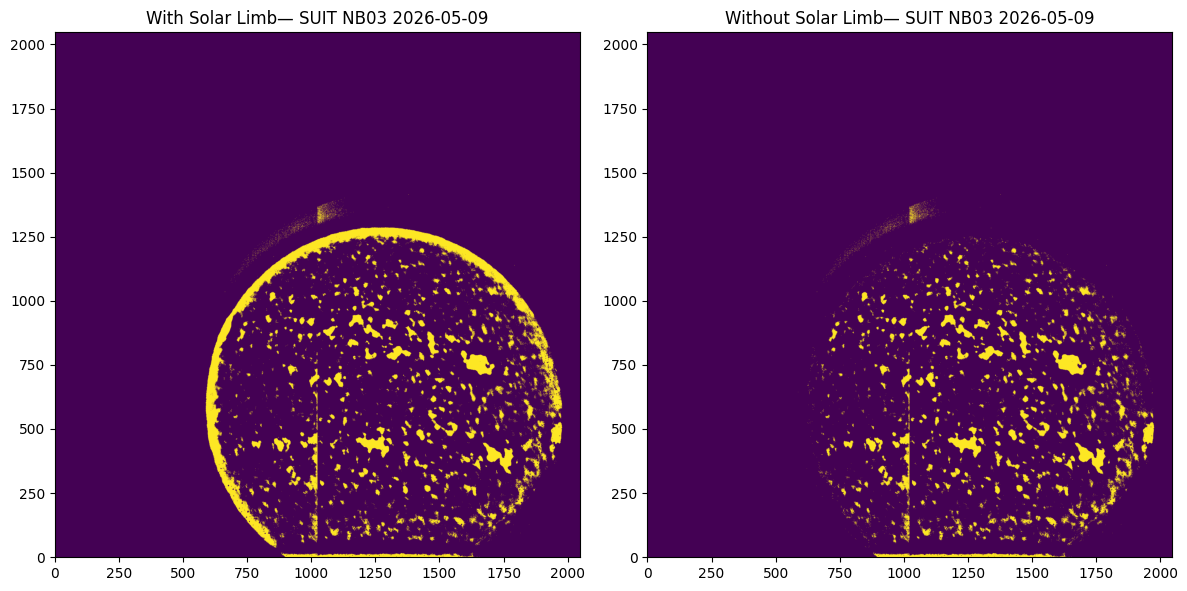

In [15]:
# Area- 95884, 7262, 6441, 5717, ...
max_threshold_area = 10000   

# I have kept a margin of around 2500 from the second largest area value so that any updations in the mask values can be accomodated by area.

bad_labels = []
for i in range(0, len(labeled_regions)):
    if (labeled_regions[i].area >= max_threshold_area):
        bad_labels.append(labeled_regions[i].label)                               
print(f'List containing labels having area higher than threshold: {bad_labels}')

updated_labels = np.isin(labeled, bad_labels)

'''Although we know that there is only one label above area 10000 still I have shown the approach that can be followed to identify bad labels with 
sufficient regard to any modification in area. '''

solar_limb_removed = (active_region_mask) & (~updated_labels)   # Array not having bad labels.

# Comparing old and new image side by side to see the visible change: 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(active_region_mask, origin='lower')
ax[0].set_title('With Solar Limb— SUIT NB03 2026-05-09')
ax[1].imshow(solar_limb_removed, origin='lower')
ax[1].set_title('Without Solar Limb— SUIT NB03 2026-05-09')

plt.tight_layout()
plt.show()

**We have successfully removed solar limb from the image.**

## Removing vertical and horizontal patches on the Solar Disk

We would have to repeat the same process but now with updated array **solar_limb_removed** and then manually find the horizontal and vertical patches. 

[np.float64(7262.0), np.float64(6441.0), np.float64(5717.0), np.float64(5028.0), np.float64(4353.0), np.float64(3376.0), np.float64(2702.0), np.float64(2480.0), np.float64(2135.0), np.float64(2036.0), np.float64(1653.0), np.float64(1627.0), np.float64(1449.0), np.float64(1362.0), np.float64(1320.0), np.float64(1285.0), np.float64(1265.0), np.float64(1225.0), np.float64(1209.0), np.float64(1139.0), np.float64(1066.0), np.float64(1010.0), np.float64(1009.0), np.float64(1006.0), np.float64(981.0), np.float64(914.0), np.float64(907.0), np.float64(897.0), np.float64(862.0), np.float64(861.0), np.float64(848.0), np.float64(833.0), np.float64(807.0), np.float64(792.0), np.float64(792.0), np.float64(787.0), np.float64(781.0), np.float64(768.0), np.float64(753.0), np.float64(733.0), np.float64(712.0), np.float64(701.0), np.float64(673.0), np.float64(665.0), np.float64(660.0), np.float64(659.0), np.float64(656.0), np.float64(642.0), np.float64(632.0), np.float64(632.0), np.float64(623.0), np.flo

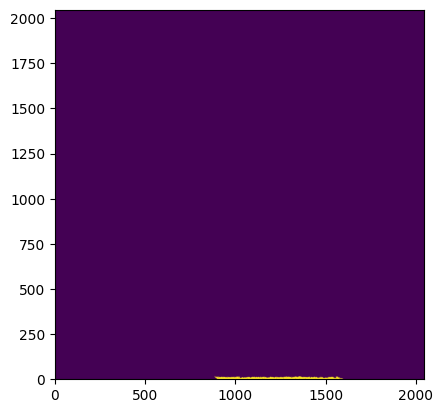

In [16]:
labeled_2 = label(solar_limb_removed)
labeled_2_regions = regionprops(labeled_2)
lst2 = []
for i in range(0, len(labeled_2_regions)):
               lst2.append(labeled_2_regions[i].area)
lst2.sort(reverse=True)
print(lst2)

for i in range(0, len(labeled_2_regions)):
        if (labeled_2_regions[i].area == 7262):
                p = labeled_2_regions[i].label
test_label_2 = (labeled_2 == p)
plt.imshow(test_label_2, origin='lower')
plt.show()

**We have successfully identified the horizontal patch which is having an area of 7262. It is located from around x=950 to around x=1600.**

Now we will remove it.

**hor_blob_removed** is the array having all the elements of the previous image except horizontal patch.

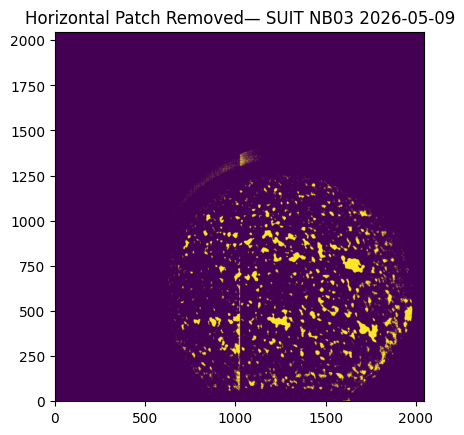

In [17]:
hor_blob_mask = (labeled_2==p)  #masking the horizontal blob that is to be removed.

hor_blob_removed = (solar_limb_removed) & (~hor_blob_mask)  # creating a new array which doesn't have the horizontal blob.
plt.imshow(hor_blob_removed, origin='lower')
plt.title('Horizontal Patch Removed— SUIT NB03 2026-05-09')
plt.savefig(r'../Outputs/Figures/Fig.7_Without_limb_and_horizontal_patch.png', dpi=150, bbox_inches='tight')
plt.show()

We have successfully removed the horizontal blob after verifying it. 

**Now moving on to find vertical patch's label**

[np.float64(7262.0), np.float64(6441.0), np.float64(5717.0), np.float64(5028.0), np.float64(4353.0), np.float64(3376.0), np.float64(2702.0), np.float64(2480.0), np.float64(2135.0), np.float64(2036.0), np.float64(1653.0), np.float64(1627.0), np.float64(1449.0), np.float64(1362.0), np.float64(1320.0), np.float64(1285.0), np.float64(1265.0), np.float64(1225.0), np.float64(1209.0), np.float64(1139.0), np.float64(1066.0), np.float64(1010.0), np.float64(1009.0), np.float64(1006.0), np.float64(981.0), np.float64(914.0), np.float64(907.0), np.float64(897.0), np.float64(862.0), np.float64(861.0), np.float64(848.0), np.float64(833.0), np.float64(807.0), np.float64(792.0), np.float64(792.0), np.float64(787.0), np.float64(781.0), np.float64(768.0), np.float64(753.0), np.float64(733.0), np.float64(712.0), np.float64(701.0), np.float64(673.0), np.float64(665.0), np.float64(660.0), np.float64(659.0), np.float64(656.0), np.float64(642.0), np.float64(632.0), np.float64(632.0), np.float64(623.0), np.flo

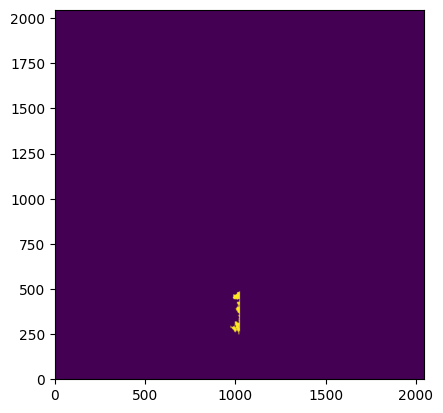

In [18]:
lst2 = []
for i in range(0, len(labeled_2_regions)):
               lst2.append(labeled_2_regions[i].area)
lst2.sort(reverse=True)
print(lst2)
p = 0
for i in range(0, len(labeled_2_regions)):
        if (labeled_2_regions[i].area == 4353):    # Checking for multiple values of area manually to locate the vertical patch.
                p = labeled_2_regions[i].label
                print(labeled_2_regions[i].area)
                print(labeled_2_regions[i].bbox)
test_label_2 = (labeled_2 == p)
plt.imshow(test_label_2, origin='lower')
plt.show()

**After successfully locating the vertical patch we will now remove it in a similar way we just did.**

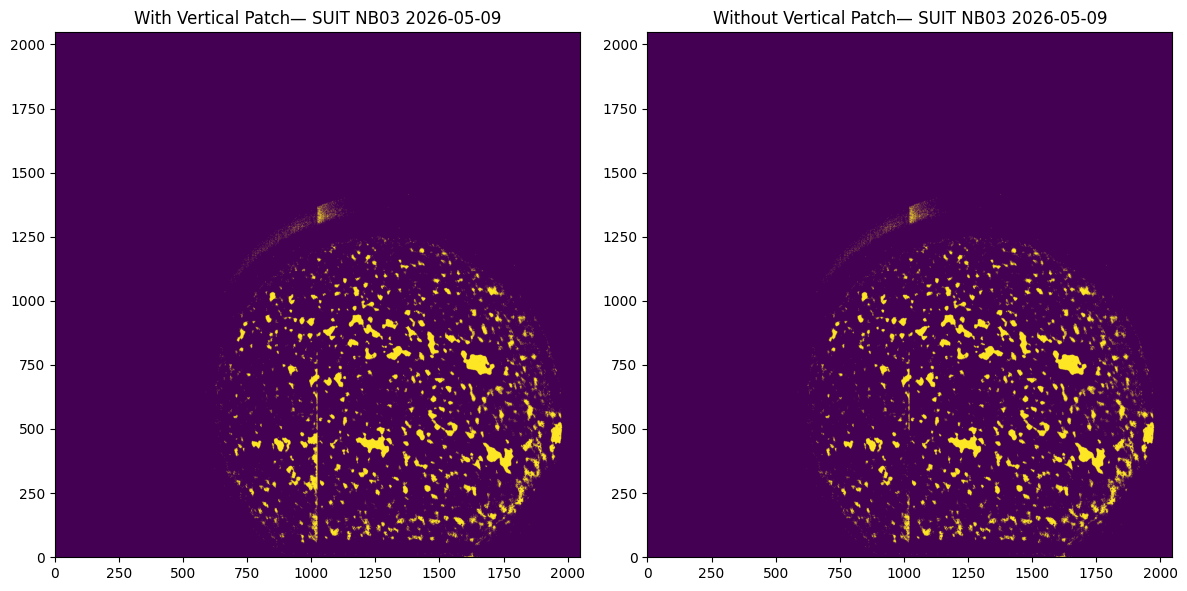

In [19]:
ver_blob_mask = (labeled_2 == p)
ver_blob_removed = (hor_blob_removed) & (~ver_blob_mask)

# Displaying graphs side by side for omparison: 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(hor_blob_removed, origin='lower')
ax[0].set_title('With Vertical Patch— SUIT NB03 2026-05-09')
ax[1].imshow(ver_blob_removed, origin='lower')
ax[1].set_title('Without Vertical Patch— SUIT NB03 2026-05-09')

plt.tight_layout()
plt.savefig(r'../Outputs/Figures/Fig.8_Without_Vertical_Patch_Image.png', dpi=150, bbox_inches='tight')
plt.show()

**After removing vertical patch, we will now try to remove or minimize the off-disk artifact located at the upper side of solar disk. Whether it can be completely removed or not depends. If its removal doesn't compromise the solar disk features then we will remove it, otherwise we will try to minimize it as much as possible.**

## Removing off-disk blob:

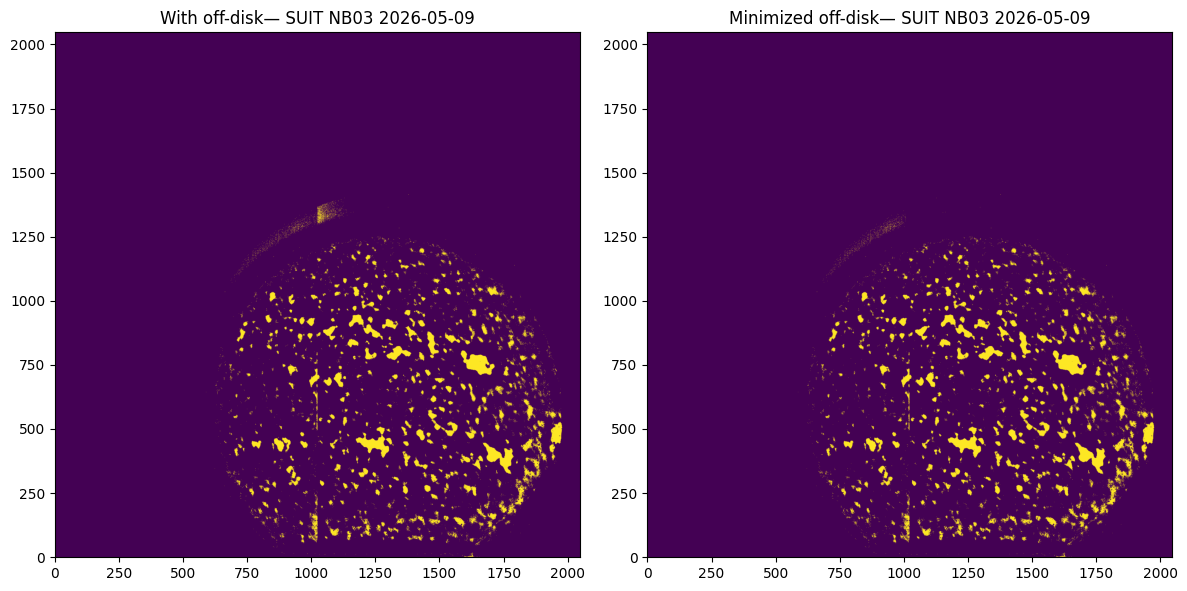

In [20]:
rows, cols = np.where(active_region_mask[1290:1400, 1010:1150])  
# These x and y coordinates have been tried for multiple combinations and at last the chosen ones ensure maximum removal without any daamage to 
# solar disk.

off_disk_masked = np.zeros(active_region_mask.shape, dtype=bool)  # Creating a new boolean array with same shape as active_region_mask and all values False. 
off_disk_masked[1290:1400, 1010:1150] = True       # Converting the False values to True for mentioned indices.
off_disk_removed = (ver_blob_removed) & (~off_disk_masked)  # Creating a new array which contains all previous features except the off-disk blob.

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(ver_blob_removed, origin='lower')
ax[0].set_title('With off-disk— SUIT NB03 2026-05-09')
ax[1].imshow(off_disk_removed, origin='lower')
ax[1].set_title('Minimized off-disk— SUIT NB03 2026-05-09')

plt.tight_layout()
plt.show()

## Observations: 

We were not able to successfully remove all of the off-disk blob because it risked damage to our solar disk. We have thus arrived at a trade-off where maximum possible off-disk blob is removed without affecting solar disk.

The reason why we were not able to remove this blob by employing the technique that we used to remove horizontal and vertical patches is that this off disk blob is not a continuous joined structure. It is made up of group of pixels which are very close to each other yet unjoined. Therefore, it could not be detected as a single area. Hence, we have applied this method of index slicing from arrays. 

**off_disk_removed** is the final array which is obtained after performing all the above steps.

## Final visualization-

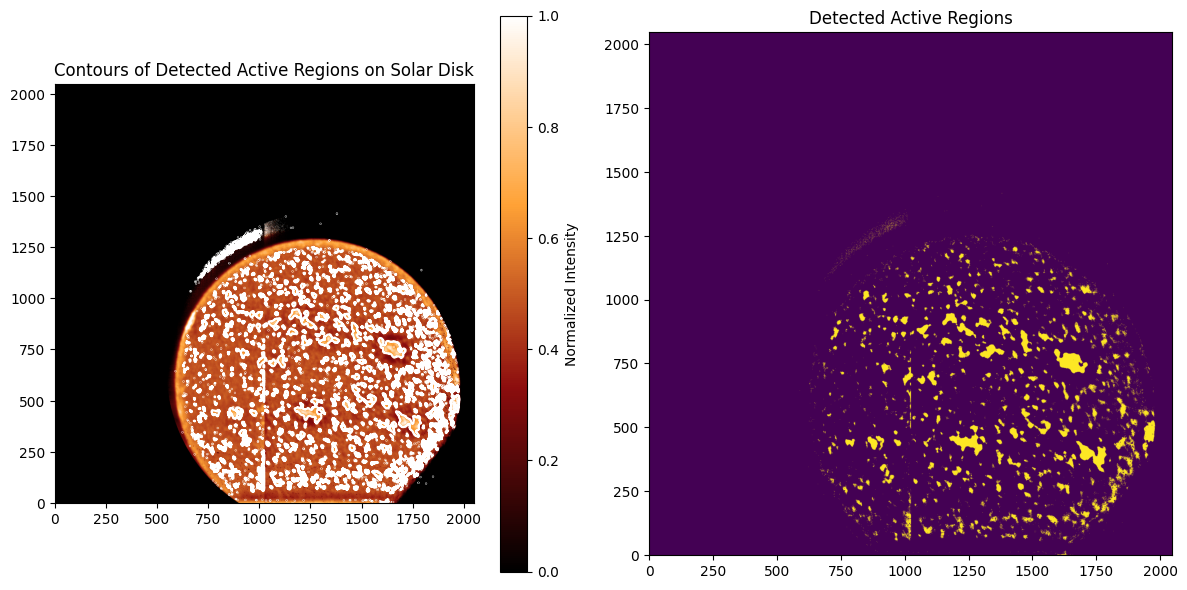

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
cmap = suit_cmap('NB03')   # false colormap for NB03 filter.
im = ax[0].imshow(arr_2d_masked, cmap=cmap, origin='lower')    # arr_2d_masked is our disk-masked, flat field corrected and normalised array.
ax[0].contour(off_disk_removed, origin='lower', colors='white')   # applying contour from the final array off_disk_removed.
ax[0].set_title('Contours of Detected Active Regions on Solar Disk')

fig.colorbar(im, ax=ax[0], label='Normalized Intensity')
ax[1].imshow(off_disk_removed, origin='lower')
ax[1].set_title('Detected Active Regions')

plt.tight_layout()
plt.savefig(r'../Outputs/Figures/Fig.9_Contour_Plot_Image.png', dpi=300, bbox_inches='tight')
plt.show()

## Observations:

We have obtained the final image with contour overlay and false-color map (**suit_cmap('NB03')**).

The false-color map provides us a clarity in identifying and distinguishing the solar phenomena and features whereas contours form boundaries of all the pixels which are being identified as active-regions.

The off-disk patch on the upper side is looking larger than that in off_disk_removed's visualization, it is because **plt.contour()** interpolates between grid points automatically hence filling the unfilled points which exist in between and therefore appearing larger. This is a property of the method and should not be treated as an error. A visual comparison I therefore made between the two to bring more clarity into the issue.

## Validation with External Catalogs (NOAA)

We have imported data from NOAA using the HEK feature of **sunpy** library dated 09/05/2026.

In [22]:
tstart = '2026/05/09 01:09:21'
tend = '2026/05/09 13:09:21'
event_type = 'AR'    # Active Regions
result = Fido.search(a.Time(tstart,tend), a.hek.EventType(event_type))
print("A look at the data:")
print(result[:10])
print(len(result[0]))

# Columns of Interest: hgs_coord and ar_noaanum


A look at the data:
Results from 1 Provider:

68 Results from the HEKClient:

                                                            gs_thumburl                                                             comment_count                              hpc_bbox                                meanphotoenergydensity  frm_humanflag           hgc_coord           ar_spotarearepruncert obs_levelnum                hpc_coord                event_npixels                                                            gs_imageurl                                                             ar_polarity                                                                                                                                                                                                                                                                              frm_paramset                                                                                                                              

We have successfully imported the data. 

The columns- **a.** "hgs_coord" stores the heliographic Stonyhurst coordinates which are of our interest as L1 point is in between sun-earth line.

**b.** "ar_noaanum" stores the number of the Active Regions as identified by NOAA. This is needed for cross verifying our data with NOAA's.

In [23]:
print(result[0]['hgs_coord','ar_noaanum'])

          hgs_coord            ar_noaanum
           deg,deg                       
------------------------------ ----------
          42.960059,-15.531834         --
          76.827034,-4.5732229         --
         0.33387134,-16.197039         --
           31.170964,12.301179         --
  -80.55896000000001,17.652663         --
            72.38547,-4.874718      14429
           28.147406,13.313002      14432
  -12.24980099999999,22.544132      14435
 -2.636977999999999,-16.874441      14433
           43.36801,-15.618754      14431
          10.420013,-12.383599         --
   -20.50366200000002,2.517395         --
            0.579506,13.396953      14434
           11.981362,17.012817         --
 -39.69935600000002,-20.065796         --
   -24.756618000000003,18.6912         --
  -81.31139999999999,18.134653      14436
           45.748703,-15.62049      14431
            2.605425,13.371636      14434
-0.5092000000000212,-16.941177      14433
          12.721033,-12.565613    

**Steps to be followed for Verification:**

**1.** We will be finding the centroids' coordinates of all the labeled regions our data. Those coordinates will be in the form of pixel coordinates. 

**2.** After getting all of them we will convert those coordinates to **Helioprojective coordinates**. 

**3.** As NOAA data is in **hgs** coordinates, we will have to covert all of our hpc coordinates to hgs.

**4.** A coordinate will be verified if it's separation from NOAA's catalog is <= 5 degrees. This is a safe approximation.

In [24]:
from skimage import measure
# We are trying to convert image pixels to Stonyhurst coordinates.
cleaned_labeled = label(off_disk_removed)
regions = measure.regionprops(cleaned_labeled)
for i in regions:
    print(i.centroid)  # NOTE: here output is in (row,col) format, pixel_to_world uses (col,row) format.

suit_map = smap
    

(np.float64(0.8), np.float64(1596.4))
(np.float64(0.45454545454545453), np.float64(1601.4545454545455))
(np.float64(2.2625), np.float64(1621.55))
(np.float64(0.3333333333333333), np.float64(1632.3333333333333))
(np.float64(0.0), np.float64(1645.0))
(np.float64(0.0), np.float64(1647.0))
(np.float64(0.0), np.float64(1656.0))
(np.float64(1.0), np.float64(1635.0))
(np.float64(2.0), np.float64(1605.0))
(np.float64(4.5), np.float64(1589.0))
(np.float64(6.5), np.float64(1551.5))
(np.float64(6.0), np.float64(1597.0))
(np.float64(7.0), np.float64(1590.0))
(np.float64(7.5), np.float64(1617.5))
(np.float64(8.0), np.float64(1623.25))
(np.float64(8.0), np.float64(1548.0))
(np.float64(11.954545454545455), np.float64(1626.4545454545455))
(np.float64(9.0), np.float64(1173.0))
(np.float64(9.0), np.float64(1504.0))
(np.float64(10.0), np.float64(1032.0))
(np.float64(10.0), np.float64(1051.0))
(np.float64(10.0), np.float64(1054.0))
(np.float64(10.0), np.float64(1508.0))
(np.float64(11.0), np.float64(1133.

In [25]:
verified_regions = []
noaa_catalog = result[0][result[0]['ar_noaanum'].filled(0) != 0]
for i in regions:
    x,y = i.centroid  # gives (row,col) form of centroids
    hpc_coord = suit_map.pixel_to_world(y * u.pixel, x * u.pixel)  #converting pixel coordinates to helioprojective coordinates
    hgs_coord = hpc_coord.transform_to(HeliographicStonyhurst)   # converting helioprojective coords to heliographic stonyhurst
    catalog_comparison = hgs_coord.separation(noaa_catalog['hgs_coord'])    # comparing the two coordinates, ie Aditya L1's and NOAA's.
    best_match_idx = np.argmin(catalog_comparison)
    if np.any(catalog_comparison <= 5 * u.deg):
        print(f'My region {i.label} matched with NOAA AR{noaa_catalog['ar_noaanum'][best_match_idx]} with a separation of {catalog_comparison[best_match_idx]} degrees.')
        verified_regions.append((i.label, noaa_catalog['ar_noaanum'][best_match_idx]))
print(verified_regions)    

 '2026-05-09T00:00:00.000' '2026-05-09T00:00:00.000'
 '2026-05-09T00:00:00.000' '2026-05-09T00:00:00.000'
 '2026-05-09T00:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T04:00:00.000'
 '2026-05-09T04:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T08:00:00.000'
 '2026-05-09T08:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000' '2026-05-09T12:00:00.000'
 '2026-05-09T12:00:00.000'], rsun=695700.0 km)> to <HeliographicStonyhurst Frame (obstime=2026-05-09T07:09:21.400, rsun=695700.0 km)>. Angular separation can depend on the direction of the transformation. [astropy.coordinates.baseframe]
2026-08-04 16:17:15 - astropy - WARNING: NonRotationTransformationWarning: transforming other coordinates from <HeliographicStonyhurst Frame (obstime=['2026-05-09T00:00:00.000' '20

My region 1839 matched with NOAA AR14431 with a separation of 0.9252874473239701 deg degrees.
My region 1965 matched with NOAA AR14431 with a separation of 4.268048546617505 deg degrees.
My region 2069 matched with NOAA AR14433 with a separation of 0.37653219871090365 deg degrees.
My region 2191 matched with NOAA AR14433 with a separation of 1.6273951570349703 deg degrees.
My region 2194 matched with NOAA AR14433 with a separation of 1.6811783140674832 deg degrees.
My region 2200 matched with NOAA AR14429 with a separation of 4.84064268090849 deg degrees.
My region 2201 matched with NOAA AR14433 with a separation of 1.8201743248269064 deg degrees.
My region 2215 matched with NOAA AR14431 with a separation of 4.610770901458597 deg degrees.
My region 2216 matched with NOAA AR14431 with a separation of 4.607703099232319 deg degrees.
My region 2272 matched with NOAA AR14433 with a separation of 2.4315683735126656 deg degrees.
My region 2279 matched with NOAA AR14433 with a separation of 2.

## Discussion: 

### Fragmentation due to Otsu Thresholding
61 blobs being mapped to only 7 NOAA regions reveals a limitation of Otsu thresholding — a single active region is broken into many smaller disconnected blobs. Otsu has only a single intensity threshold, due to which we are getting a single active region being identified multiple times.

### Off-disk NaN Warnings
Several detected blobs had centroids falling outside the solar disk, producing NaN coordinates during transformation.

### Known Limitations
- Single global Otsu threshold causes fragmentation of active regions
- Since this is performed on a single image, temporal tracking is not possible. 

In [26]:
# Finding the unique regions: 
print(len(verified_regions))

unique_noaa = set([t[1] for t in verified_regions])
print(f"Unique NOAA ARs matched: {unique_noaa}")
print(f"Total verified blobs: {len(verified_regions)}")

61
Unique NOAA ARs matched: {np.int32(14432), np.int32(14433), np.int32(14434), np.int32(14435), np.int32(14436), np.int32(14429), np.int32(14431)}
Total verified blobs: 61


**Solar Cycle Context:**
May 9, 2026 falls in the declining phase of Solar Cycle 25, which exited solar maximum around February 2026. Activity was still significant but decreasing.

**Sunspot-Active Region relationship:**
Sunspots are the most visible feature of active regions, appearing dark due to strong magnetic fields suppressing convection. The magnetic complexity of a sunspot group determines its flaring potential.

**CME correlation — a major finding:**
AR14436 was detected by our pipeline on May 9. The very next day it produced an M5.7 flare and a CME travelling at ~650 km/s. This means our pipeline identified a pre-eruptive active region before it erupted. This is a result which validates our pipeline.

**AR14432:**
Showed elevated C-class flare activity around the observation date with evolving magnetic polarity — another region worth noting.

In [27]:
np.save(r"..\Data\Processed\arr_2d_masked.npy", arr_2d_masked)
np.save(r'..\Data\Processed\off_disk_removed.npy',off_disk_removed)